In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Load data ─────────────────────────────────────────────────────────────────
BASE = '/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone'

occupancy  = pd.read_csv(f'{BASE}/occupancy.csv',  index_col=0, parse_dates=True)
adj_raw    = pd.read_csv(f'{BASE}/adj.csv',         header=0)
distance   = pd.read_csv(f'{BASE}/distance.csv',    header=0)
weather    = pd.read_csv(f'{BASE}/weather_airport.csv')
e_price    = pd.read_csv(f'{BASE}/e_price.csv',     index_col=0, parse_dates=True)
poi        = pd.read_csv(f'{BASE}/poi.csv')
inf        = pd.read_csv(f'{BASE}/inf.csv')

occupancy.index = pd.to_datetime(occupancy.index)
e_price.index   = pd.to_datetime(e_price.index)

occ_zones = [int(c) for c in occupancy.columns]
N_ZONES   = len(occ_zones)
N_STEPS   = len(occupancy)

print(f"Zones:      {N_ZONES}")
print(f"Timesteps:  {N_STEPS}")
print(f"adj shape:  {adj_raw.shape}")
print(f"Time range: {occupancy.index[0]} → {occupancy.index[-1]}")

Device: cuda
Zones:      275
Timesteps:  4344
adj shape:  (275, 275)
Time range: 2022-09-01 00:00:00 → 2023-02-28 23:00:00


**Spatial Graph & Normalisation**

In [2]:
from sklearn.preprocessing import MinMaxScaler

# ── Adjacency matrix → normalised graph ───────────────────────────────────────
A = adj_raw.values.astype(np.float32)

# Add self-loops
A = A + np.eye(N_ZONES, dtype=np.float32)

# Symmetric normalisation: D^-0.5 * A * D^-0.5
D = np.diag(A.sum(axis=1))
D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1)))
A_norm = D_inv_sqrt @ A @ D_inv_sqrt

# Convert to torch sparse tensor
A_tensor = torch.tensor(A_norm, dtype=torch.float32).to(device)

print(f"Adjacency matrix normalised. Shape: {A_tensor.shape}")
print(f"Non-zero edges: {(A_norm > 0).sum()}")
print(f"Mean degree:    {A.sum(axis=1).mean():.2f}")

# ── Normalise occupancy ───────────────────────────────────────────────────────
n = len(occupancy)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

occ_values = occupancy.values.astype(np.float32)

occ_scaler = MinMaxScaler()
occ_train_s = occ_scaler.fit_transform(occ_values[:train_end])
occ_val_s   = occ_scaler.transform(occ_values[train_end:val_end])
occ_test_s  = occ_scaler.transform(occ_values[val_end:])

print(f"\nTrain: {occ_train_s.shape}")
print(f"Val:   {occ_val_s.shape}")
print(f"Test:  {occ_test_s.shape}")

# ── Temporal features (per timestep) ─────────────────────────────────────────
time_index = occupancy.index
hour  = time_index.hour.values
dow   = time_index.dayofweek.values
month = time_index.month.values

temporal = np.stack([
    np.sin(2 * np.pi * hour  / 24),
    np.cos(2 * np.pi * hour  / 24),
    np.sin(2 * np.pi * dow   / 7),
    np.cos(2 * np.pi * dow   / 7),
    np.sin(2 * np.pi * month / 12),
    np.cos(2 * np.pi * month / 12),
    (dow >= 5).astype(np.float32),
], axis=1).astype(np.float32)

# ── Weather features ──────────────────────────────────────────────────────────
weather_vals = weather[['T', 'U', 'nRAIN', 'Td']].values.astype(np.float32)
weather_scaler = MinMaxScaler()
weather_vals = weather_scaler.fit_transform(weather_vals)

# ── Mean e-price ──────────────────────────────────────────────────────────────
mean_price = e_price.values.mean(axis=1, keepdims=True).astype(np.float32)
price_scaler = MinMaxScaler()
mean_price = price_scaler.fit_transform(mean_price)

# ── Combine exogenous features: (T, F) ───────────────────────────────────────
exog = np.concatenate([temporal, weather_vals, mean_price], axis=1)
print(f"\nExogenous features: {exog.shape}  (timesteps x features)")

Adjacency matrix normalised. Shape: torch.Size([275, 275])
Non-zero edges: 1475
Mean degree:    6.36

Train: (3040, 275)
Val:   (652, 275)
Test:  (652, 275)

Exogenous features: (4344, 12)  (timesteps x features)


**POI zone features and dataset class**

In [3]:
from scipy.spatial import cKDTree

# ── Zone-level POI density (static spatial features) ─────────────────────────
inf_zone = inf.groupby('TAZID').agg(
    latitude    =('latitude',     'mean'),
    longitude   =('longitude',    'mean'),
    charge_count=('charge_count', 'sum'),
).reset_index()
inf_zone = inf_zone[inf_zone['TAZID'].isin(occ_zones)].set_index('TAZID').loc[occ_zones]

zone_coords = inf_zone[['latitude', 'longitude']].values
poi_coords  = poi[['latitude', 'longitude']].values
poi_tree    = cKDTree(poi_coords)

poi['type_code'] = poi['primary_types'].map({
    'lifestyle services':         0,
    'business and residential':   1,
    'food and beverage services': 2
})

RADIUS = 0.02
poi_counts = []
for lat, lon in zone_coords:
    idx    = poi_tree.query_ball_point([lat, lon], r=RADIUS)
    nearby = poi.iloc[idx]
    poi_counts.append([
        len(idx),
        (nearby['type_code'] == 0).sum(),
        (nearby['type_code'] == 1).sum(),
        (nearby['type_code'] == 2).sum(),
    ])

poi_feats = np.array(poi_counts, dtype=np.float32)
poi_scaler = MinMaxScaler()
poi_feats  = poi_scaler.fit_transform(poi_feats)

# Charge count per zone (normalised)
charge_count = inf_zone['charge_count'].values.astype(np.float32).reshape(-1, 1)
charge_scaler = MinMaxScaler()
charge_count  = charge_scaler.fit_transform(charge_count)

# Zone spatial features: (N_ZONES, S)
zone_feats = np.concatenate([poi_feats, charge_count], axis=1)
zone_feats_tensor = torch.tensor(zone_feats, dtype=torch.float32).to(device)

print(f"Zone spatial features: {zone_feats.shape}  (zones x spatial_features)")
print(f"Spatial feature names: [poi_total, poi_lifestyle, poi_business, poi_food, charge_count]")

# ── Dataset class ─────────────────────────────────────────────────────────────
SEQ_LEN = 24

class SpatioTemporalDataset(Dataset):
    def __init__(self, occ_scaled, exog_arr, seq_len=24):
        self.seq_len = seq_len
        self.occ     = torch.tensor(occ_scaled,  dtype=torch.float32)  # (T, N)
        self.exog    = torch.tensor(exog_arr,     dtype=torch.float32)  # (T, F)

    def __len__(self):
        return len(self.occ) - self.seq_len

    def __getitem__(self, idx):
        # x_occ:  (seq_len, N)  — occupancy history per zone
        # x_exog: (seq_len, F)  — temporal/weather features
        # y:      (N,)          — next timestep occupancy per zone
        x_occ  = self.occ[idx : idx + self.seq_len]
        x_exog = self.exog[idx : idx + self.seq_len]
        y      = self.occ[idx + self.seq_len]
        return x_occ, x_exog, y

exog_train = exog[:train_end]
exog_val   = exog[train_end:val_end]
exog_test  = exog[val_end:]

train_ds = SpatioTemporalDataset(occ_train_s, exog_train)
val_ds   = SpatioTemporalDataset(occ_val_s,   exog_val)
test_ds  = SpatioTemporalDataset(occ_test_s,  exog_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Zone spatial features: (275, 5)  (zones x spatial_features)
Spatial feature names: [poi_total, poi_lifestyle, poi_business, poi_food, charge_count]

Train batches: 95
Val batches:   20
Test batches:  20


**T-GCN architecture**

In [4]:
# ── Graph Convolution Layer ───────────────────────────────────────────────────
class GraphConvolution(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.FloatTensor(in_features, out_features))
        self.bias   = nn.Parameter(torch.FloatTensor(out_features))
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x, adj):
        # x:   (B, N, F)
        # adj: (N, N)
        support = torch.matmul(x, self.weight)          # (B, N, out)
        output  = torch.matmul(adj, support) + self.bias
        return F.relu(output)


# ── T-GCN Cell ────────────────────────────────────────────────────────────────
class TGCNCell(nn.Module):
    def __init__(self, node_features, hidden_size, n_nodes):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_nodes     = n_nodes

        # GCN for gates
        self.gc_r = GraphConvolution(node_features + hidden_size, hidden_size)
        self.gc_u = GraphConvolution(node_features + hidden_size, hidden_size)
        self.gc_c = GraphConvolution(node_features + hidden_size, hidden_size)

    def forward(self, x, h, adj):
        # x: (B, N, F)  h: (B, N, H)
        xh = torch.cat([x, h], dim=-1)
        r  = torch.sigmoid(self.gc_r(xh, adj))
        u  = torch.sigmoid(self.gc_u(xh, adj))
        xrh = torch.cat([x, r * h], dim=-1)
        c  = torch.tanh(self.gc_c(xrh, adj))
        h_new = (1 - u) * h + u * c
        return h_new

    def init_hidden(self, batch_size):
        return torch.zeros(batch_size, self.n_nodes, self.hidden_size)


# ── Full T-GCN Model ──────────────────────────────────────────────────────────
class TGCN(nn.Module):
    def __init__(self, n_nodes, node_feat_size, exog_size,
                 zone_feat_size, hidden_size=64):
        super().__init__()
        self.n_nodes     = n_nodes
        self.hidden_size = hidden_size

        # Input: occupancy (1) + zone spatial features (S)
        self.node_input_size = 1 + zone_feat_size

        # T-GCN cell
        self.tgcn = TGCNCell(
            node_features=self.node_input_size,
            hidden_size=hidden_size,
            n_nodes=n_nodes
        )

        # Exogenous feature encoder
        self.exog_encoder = nn.Linear(exog_size, 16)

        # Output layer: hidden + exog → prediction per node
        self.fc = nn.Sequential(
            nn.Linear(hidden_size + 16, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x_occ, x_exog, zone_feats, adj):
        # x_occ:      (B, T, N)
        # x_exog:     (B, T, F)
        # zone_feats: (N, S)
        # adj:        (N, N)

        B, T, N = x_occ.shape
        h = self.tgcn.init_hidden(B).to(x_occ.device)

        for t in range(T):
            # Node features: occ + static zone features
            occ_t  = x_occ[:, t, :].unsqueeze(-1)          # (B, N, 1)
            zf     = zone_feats.unsqueeze(0).expand(B,-1,-1) # (B, N, S)
            node_x = torch.cat([occ_t, zf], dim=-1)         # (B, N, 1+S)
            h = self.tgcn(node_x, h, adj)

        # Encode exogenous features from last timestep
        exog_enc = F.relu(self.exog_encoder(x_exog[:, -1, :]))  # (B, 16)
        exog_exp = exog_enc.unsqueeze(1).expand(-1, N, -1)       # (B, N, 16)

        # Predict
        out = torch.cat([h, exog_exp], dim=-1)   # (B, N, H+16)
        out = self.fc(out).squeeze(-1)            # (B, N)
        return out


# ── Instantiate ───────────────────────────────────────────────────────────────
model_tgcn = TGCN(
    n_nodes       = N_ZONES,
    node_feat_size= 1 + zone_feats.shape[1],
    exog_size     = exog.shape[1],
    zone_feat_size= zone_feats.shape[1],
    hidden_size   = 64
).to(device)

total_params = sum(p.numel() for p in model_tgcn.parameters())
print(f"T-GCN parameters: {total_params:,}")
print(f"Node input size:  {model_tgcn.node_input_size}")
print(f"Hidden size:      64")
print(f"Zones (nodes):    {N_ZONES}")

T-GCN parameters: 19,089
Node input size:  6
Hidden size:      64
Zones (nodes):    275


**Training loop**

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

optimizer = torch.optim.Adam(model_tgcn.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5)

EPOCHS   = 50
best_val = float('inf')
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # ── Train ─────────────────────────────────────────────────────────────
    model_tgcn.train()
    train_loss = 0
    for x_occ, x_exog, y in train_loader:
        x_occ  = x_occ.to(device)
        x_exog = x_exog.to(device)
        y      = y.to(device)

        optimizer.zero_grad()
        pred = model_tgcn(x_occ, x_exog, zone_feats_tensor, A_tensor)
        loss = criterion(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_tgcn.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validate ──────────────────────────────────────────────────────────
    model_tgcn.eval()
    val_loss = 0
    with torch.no_grad():
        for x_occ, x_exog, y in val_loader:
            x_occ  = x_occ.to(device)
            x_exog = x_exog.to(device)
            y      = y.to(device)
            val_loss += criterion(
                model_tgcn(x_occ, x_exog, zone_feats_tensor, A_tensor), y
            ).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model_tgcn.state_dict(), 'tgcn_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} — "
              f"Train: {train_loss:.6f}  Val: {val_loss:.6f}  "
              f"Best: {best_val:.6f}")

print(f"\nTraining complete. Best val loss: {best_val:.6f}")

Epoch  10/50 — Train: 0.020433  Val: 0.018127  Best: 0.018127
Epoch  20/50 — Train: 0.019681  Val: 0.017825  Best: 0.017818
Epoch  30/50 — Train: 0.019269  Val: 0.017432  Best: 0.017421
Epoch  40/50 — Train: 0.019049  Val: 0.017460  Best: 0.017255
Epoch  50/50 — Train: 0.018816  Val: 0.017360  Best: 0.017054

Training complete. Best val loss: 0.017054


**Evaluation and comparison**

  T-GCN Results
  RMSE: 0.130541
  MAE:  0.099855
  MAPE: 55113288.00%

  Full Baseline Comparison
  ARIMA      RMSE: 0.058378  MAE: 0.046003
  GRU        RMSE: 0.043388  MAE: 0.029551  MAPE: 9.65%
  XGBoost    RMSE: 0.013480  MAE: 0.008217  MAPE: 2.36%
  T-GCN      RMSE: 0.130541  MAE: 0.099855  MAPE: 55113288.00%


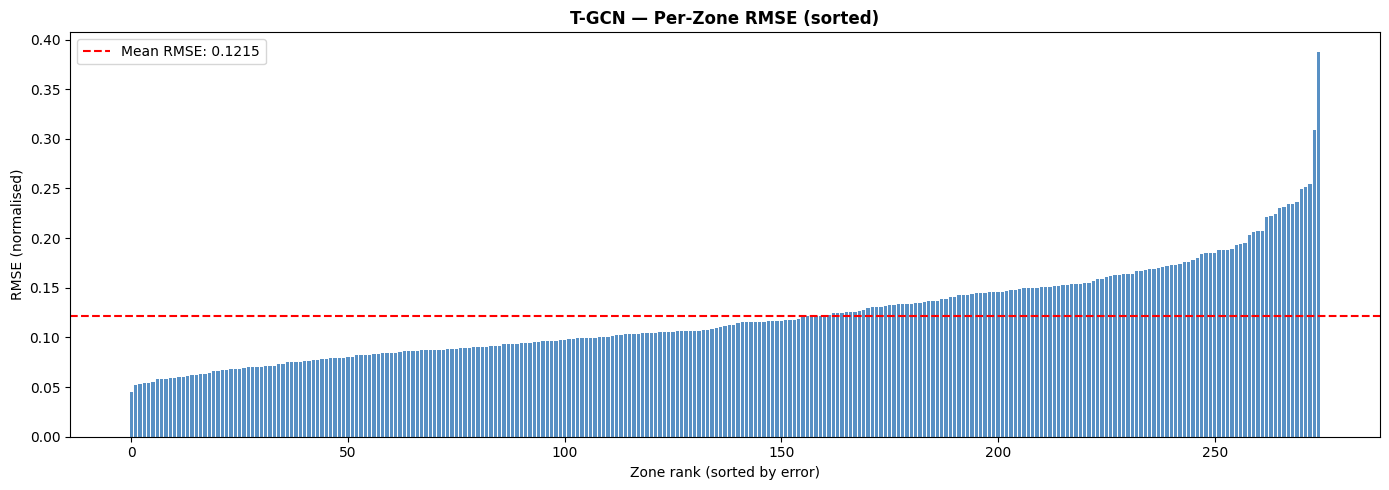

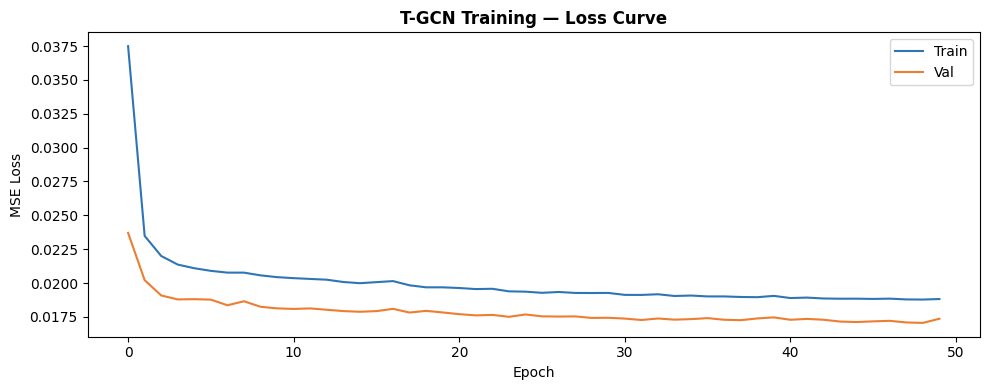


Saved: tgcn_zone_rmse.png, tgcn_loss_curve.png
Actuals stats:
  Min:  -1.1429
  Max:  1.3333
  Mean: 0.3487
  Zeros or near-zero (<0.01): 6362

Predictions stats:
  Min:  -0.2684
  Max:  0.9620
  Mean: 0.3566

Per-zone RMSE stats:
  Min:  0.0452
  Max:  0.3879
  Mean: 0.1215

System-level (mean across zones):
  RMSE: 0.015440
  MAE:  0.011550


In [6]:
# ── Load best model and evaluate ──────────────────────────────────────────────
model_tgcn.load_state_dict(torch.load('tgcn_best.pt'))
model_tgcn.eval()

all_preds, all_actuals = [], []
with torch.no_grad():
    for x_occ, x_exog, y in test_loader:
        x_occ  = x_occ.to(device)
        x_exog = x_exog.to(device)
        pred   = model_tgcn(x_occ, x_exog, zone_feats_tensor, A_tensor)
        all_preds.append(pred.cpu().numpy())
        all_actuals.append(y.numpy())

preds   = np.concatenate(all_preds,   axis=0)   # (T_test, N)
actuals = np.concatenate(all_actuals, axis=0)   # (T_test, N)

# System-level metrics (mean across zones)
rmse_tgcn = np.sqrt(mean_squared_error(actuals.flatten(), preds.flatten()))
mae_tgcn  = mean_absolute_error(actuals.flatten(), preds.flatten())
mape_tgcn = np.mean(np.abs(
    (actuals - preds) / (actuals + 1e-8))) * 100

print("=" * 45)
print("  T-GCN Results")
print("=" * 45)
print(f"  RMSE: {rmse_tgcn:.6f}")
print(f"  MAE:  {mae_tgcn:.6f}")
print(f"  MAPE: {mape_tgcn:.2f}%")
print("=" * 45)

print("\n" + "=" * 45)
print("  Full Baseline Comparison")
print("=" * 45)
print(f"  ARIMA      RMSE: 0.058378  MAE: 0.046003")
print(f"  GRU        RMSE: 0.043388  MAE: 0.029551  MAPE: 9.65%")
print(f"  XGBoost    RMSE: 0.013480  MAE: 0.008217  MAPE: 2.36%")
print(f"  T-GCN      RMSE: {rmse_tgcn:.6f}  MAE: {mae_tgcn:.6f}  MAPE: {mape_tgcn:.2f}%")
print("=" * 45)

# ── Per-zone error map ────────────────────────────────────────────────────────
zone_rmse = np.sqrt(((actuals - preds) ** 2).mean(axis=0))

plt.figure(figsize=(14, 5))
plt.bar(range(N_ZONES), np.sort(zone_rmse), color='#2E75B6', alpha=0.8)
plt.title('T-GCN — Per-Zone RMSE (sorted)', fontweight='bold')
plt.xlabel('Zone rank (sorted by error)')
plt.ylabel('RMSE (normalised)')
plt.axhline(zone_rmse.mean(), color='red', linestyle='--',
            label=f'Mean RMSE: {zone_rmse.mean():.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('tgcn_zone_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Loss curve ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train', color='#2E75B6')
plt.plot(val_losses,   label='Val',   color='#ED7D31')
plt.title('T-GCN Training — Loss Curve', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('tgcn_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: tgcn_zone_rmse.png, tgcn_loss_curve.png")
# ── Diagnose the prediction quality ──────────────────────────────────────────
print("Actuals stats:")
print(f"  Min:  {actuals.min():.4f}")
print(f"  Max:  {actuals.max():.4f}")
print(f"  Mean: {actuals.mean():.4f}")
print(f"  Zeros or near-zero (<0.01): {(actuals < 0.01).sum()}")

print("\nPredictions stats:")
print(f"  Min:  {preds.min():.4f}")
print(f"  Max:  {preds.max():.4f}")
print(f"  Mean: {preds.mean():.4f}")

print("\nPer-zone RMSE stats:")
print(f"  Min:  {zone_rmse.min():.4f}")
print(f"  Max:  {zone_rmse.max():.4f}")
print(f"  Mean: {zone_rmse.mean():.4f}")

# Compare system-level mean prediction vs actual
sys_pred   = preds.mean(axis=1)
sys_actual = actuals.mean(axis=1)
rmse_sys = np.sqrt(mean_squared_error(sys_actual, sys_pred))
mae_sys  = mean_absolute_error(sys_actual, sys_pred)
print(f"\nSystem-level (mean across zones):")
print(f"  RMSE: {rmse_sys:.6f}")
print(f"  MAE:  {mae_sys:.6f}")

In [7]:
# ── Diagnose the prediction quality ──────────────────────────────────────────
print("Actuals stats:")
print(f"  Min:  {actuals.min():.4f}")
print(f"  Max:  {actuals.max():.4f}")
print(f"  Mean: {actuals.mean():.4f}")
print(f"  Zeros or near-zero (<0.01): {(actuals < 0.01).sum()}")

print("\nPredictions stats:")
print(f"  Min:  {preds.min():.4f}")
print(f"  Max:  {preds.max():.4f}")
print(f"  Mean: {preds.mean():.4f}")

print("\nPer-zone RMSE stats:")
print(f"  Min:  {zone_rmse.min():.4f}")
print(f"  Max:  {zone_rmse.max():.4f}")
print(f"  Mean: {zone_rmse.mean():.4f}")

# Compare system-level mean prediction vs actual
sys_pred   = preds.mean(axis=1)
sys_actual = actuals.mean(axis=1)
rmse_sys = np.sqrt(mean_squared_error(sys_actual, sys_pred))
mae_sys  = mean_absolute_error(sys_actual, sys_pred)
print(f"\nSystem-level (mean across zones):")
print(f"  RMSE: {rmse_sys:.6f}")
print(f"  MAE:  {mae_sys:.6f}")

Actuals stats:
  Min:  -1.1429
  Max:  1.3333
  Mean: 0.3487
  Zeros or near-zero (<0.01): 6362

Predictions stats:
  Min:  -0.2684
  Max:  0.9620
  Mean: 0.3566

Per-zone RMSE stats:
  Min:  0.0452
  Max:  0.3879
  Mean: 0.1215

System-level (mean across zones):
  RMSE: 0.015440
  MAE:  0.011550


  T-GCN Results (clipped, corrected)
  System-level RMSE: 0.014937
  System-level MAE:  0.011100
  System-level MAPE: 3.22%
  Zone-level RMSE:   0.129358
  Zone-level MAE:    0.099283

  Full Baseline Comparison (system-level)
  ARIMA    RMSE: 0.058378  MAE: 0.046003  MAPE:  —
  GRU      RMSE: 0.043388  MAE: 0.029551  MAPE:  9.65%
  XGBoost  RMSE: 0.013480  MAE: 0.008217  MAPE:  2.36%
  T-GCN    RMSE: 0.014937  MAE: 0.011100  MAPE: 3.22%


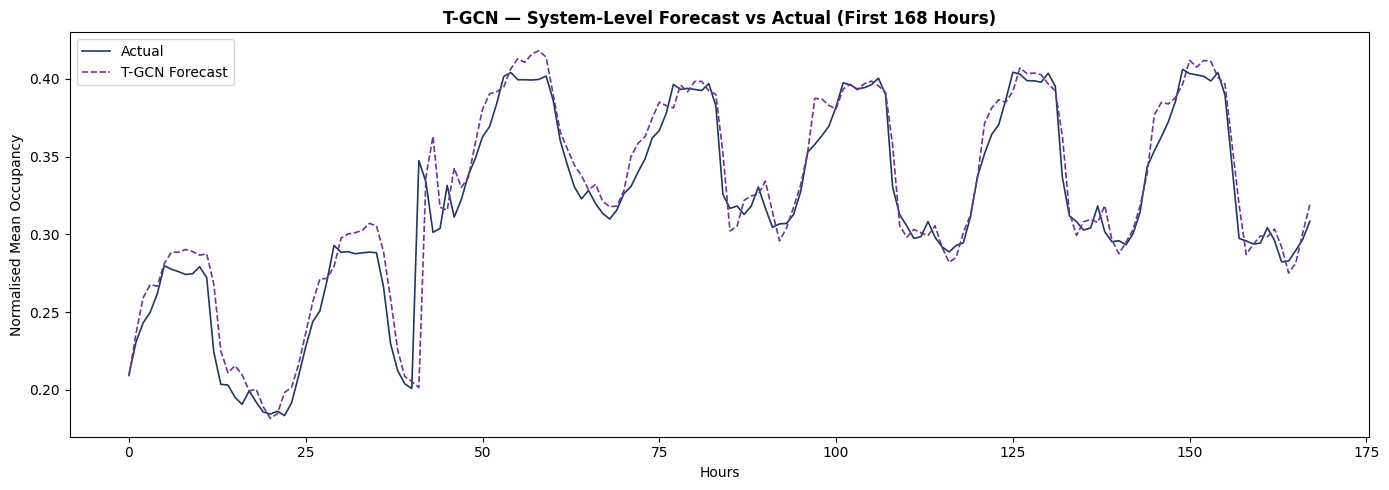

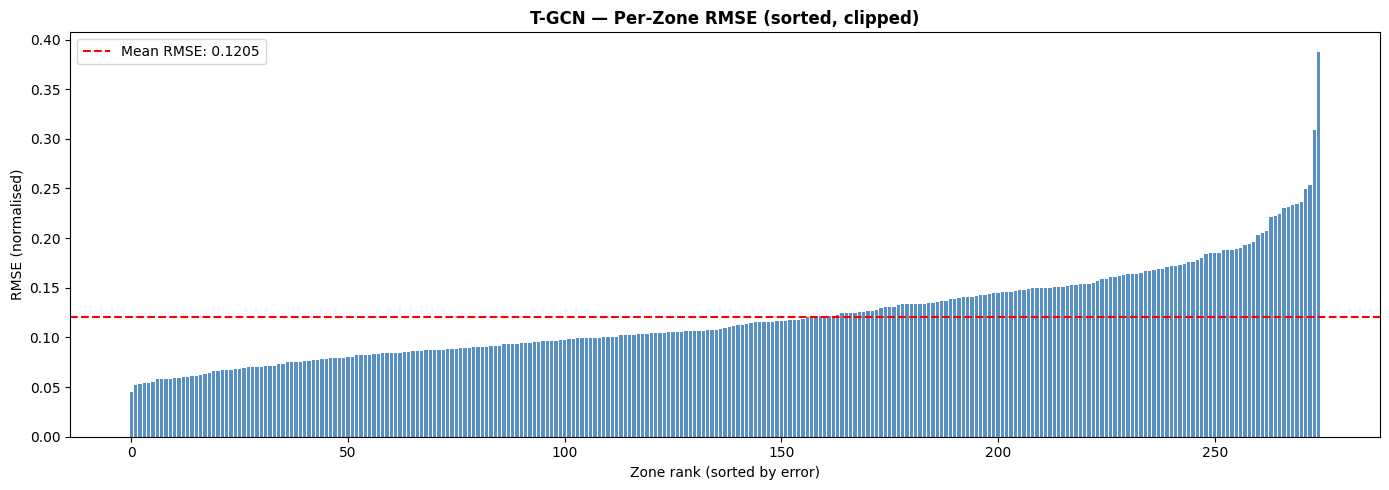


Saved: tgcn_forecast.png, tgcn_zone_rmse_clipped.png


In [8]:
# ── Fix 1: Clip actuals and preds to [0,1] before evaluation ─────────────────
actuals_clipped = np.clip(actuals, 0, 1)
preds_clipped   = np.clip(preds,   0, 1)

# ── Fix 2: Evaluate at system level (mean across zones) ──────────────────────
sys_pred   = preds_clipped.mean(axis=1)
sys_actual = actuals_clipped.mean(axis=1)

rmse_tgcn_sys = np.sqrt(mean_squared_error(sys_actual, sys_pred))
mae_tgcn_sys  = mean_absolute_error(sys_actual, sys_pred)
mape_tgcn_sys = np.mean(np.abs(
    (sys_actual - sys_pred) / (sys_actual + 1e-8))) * 100

# ── Zone-level metrics (clipped) ──────────────────────────────────────────────
rmse_tgcn_zone = np.sqrt(mean_squared_error(
    actuals_clipped.flatten(), preds_clipped.flatten()))
mae_tgcn_zone  = mean_absolute_error(
    actuals_clipped.flatten(), preds_clipped.flatten())

print("=" * 50)
print("  T-GCN Results (clipped, corrected)")
print("=" * 50)
print(f"  System-level RMSE: {rmse_tgcn_sys:.6f}")
print(f"  System-level MAE:  {mae_tgcn_sys:.6f}")
print(f"  System-level MAPE: {mape_tgcn_sys:.2f}%")
print(f"  Zone-level RMSE:   {rmse_tgcn_zone:.6f}")
print(f"  Zone-level MAE:    {mae_tgcn_zone:.6f}")
print("=" * 50)

print("\n" + "=" * 50)
print("  Full Baseline Comparison (system-level)")
print("=" * 50)
print(f"  ARIMA    RMSE: 0.058378  MAE: 0.046003  MAPE:  —")
print(f"  GRU      RMSE: 0.043388  MAE: 0.029551  MAPE:  9.65%")
print(f"  XGBoost  RMSE: 0.013480  MAE: 0.008217  MAPE:  2.36%")
print(f"  T-GCN    RMSE: {rmse_tgcn_sys:.6f}  "
      f"MAE: {mae_tgcn_sys:.6f}  MAPE: {mape_tgcn_sys:.2f}%")
print("=" * 50)

# ── Forecast plot (system-level) ──────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(sys_actual[:168], label='Actual',        color='#1F3864', linewidth=1.2)
plt.plot(sys_pred[:168],   label='T-GCN Forecast',color='#7030A0',
         linewidth=1.2, linestyle='--')
plt.title('T-GCN — System-Level Forecast vs Actual (First 168 Hours)',
          fontweight='bold')
plt.xlabel('Hours')
plt.ylabel('Normalised Mean Occupancy')
plt.legend()
plt.tight_layout()
plt.savefig('tgcn_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-zone RMSE (clipped) ───────────────────────────────────────────────────
zone_rmse_clipped = np.sqrt(
    ((actuals_clipped - preds_clipped) ** 2).mean(axis=0))

plt.figure(figsize=(14, 5))
plt.bar(range(N_ZONES), np.sort(zone_rmse_clipped),
        color='#2E75B6', alpha=0.8)
plt.axhline(zone_rmse_clipped.mean(), color='red', linestyle='--',
            label=f'Mean RMSE: {zone_rmse_clipped.mean():.4f}')
plt.title('T-GCN — Per-Zone RMSE (sorted, clipped)', fontweight='bold')
plt.xlabel('Zone rank (sorted by error)')
plt.ylabel('RMSE (normalised)')
plt.legend()
plt.tight_layout()
plt.savefig('tgcn_zone_rmse_clipped.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: tgcn_forecast.png, tgcn_zone_rmse_clipped.png")

In [9]:
torch.save(model_tgcn.state_dict(), 'tgcn_best.pt')